<a href="https://colab.research.google.com/github/it0770e/xai-ids/blob/main/shap_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# ============================================
# CELL 1: Mount Drive and install SHAP
# ============================================
from google.colab import drive
drive.mount('/content/drive')  # Fixed: added missing quote

# Install SHAP
!pip install shap

# Clone repo
!git clone https://github.com/i10770e/xai-ids.git
%cd xai-ids

import numpy as np
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("✅ Setup complete!")
print(f"📊 SHAP version: {shap.__version__}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Cloning into 'xai-ids'...
fatal: could not read Username for 'https://github.com': No such device or address
[Errno 2] No such file or directory: 'xai-ids'
/content
✅ Setup complete!
📊 SHAP version: 0.51.0


In [9]:
# ============================================
# CELL 2: Load Random Forest model and test data
# ============================================

# Load the model
rf_model = joblib.load('/content/drive/MyDrive/xai-ids/results/models/random_forest.pkl')
print("✅ Random Forest model loaded")

# Load test data
data_path = '/content/drive/MyDrive/xai-ids/data/processed/nsl_kdd_processed.pkl'
data = joblib.load(data_path)
X_test = data['X_test']
y_test = data['y_test']

print(f"📊 Test data shape: {X_test.shape}")

# Take a smaller sample for SHAP (faster computation)
X_sample = X_test[:100]  # First 100 test samples
print(f"📊 Using {len(X_sample)} samples for SHAP analysis")

✅ Random Forest model loaded
📊 Test data shape: (22544, 41)
📊 Using 100 samples for SHAP analysis


In [10]:
# ============================================
# CELL 3: Create SHAP explainer
# ============================================

print("🔍 Creating TreeExplainer for Random Forest...")
explainer = shap.TreeExplainer(rf_model)
print("✅ Explainer created!")

# Calculate SHAP values
print("\n⚙️ Calculating SHAP values (this may take 2-3 minutes)...")
shap_values = explainer.shap_values(X_sample)

print("✅ SHAP values calculated!")
print(f"   Shape of SHAP values: {np.array(shap_values).shape}")

🔍 Creating TreeExplainer for Random Forest...
✅ Explainer created!

⚙️ Calculating SHAP values (this may take 2-3 minutes)...
✅ SHAP values calculated!
   Shape of SHAP values: (100, 41, 2)


In [12]:
# ============================================
# CELL 4: Global Feature Importance (DEBUGGED)
# ============================================

# For binary classification, shap_values is a list [values for class 0, values for class 1]
# We want the importance for attack detection (class 1)
if isinstance(shap_values, list):
    # Take absolute values and mean across samples
    shap_importance = np.abs(shap_values[1]).mean(axis=0)
else:
    shap_importance = np.abs(shap_values).mean(axis=0)

# Print shapes to debug
print(f"📊 shap_importance shape before: {shap_importance.shape}")

# Ensure it's 1-dimensional
shap_importance = np.array(shap_importance).flatten()
print(f"📊 shap_importance shape after flatten: {shap_importance.shape}")

# Get feature names - use the actual number of features from data
n_features = X_sample.shape[1]
print(f"📊 Number of features in data: {n_features}")
print(f"📊 Length of importance values: {len(shap_importance)}")

# Adjust if lengths don't match
if len(shap_importance) != n_features:
    print(f"⚠️ Length mismatch! Truncating to {min(len(shap_importance), n_features)}")
    min_len = min(len(shap_importance), n_features)
    shap_importance = shap_importance[:min_len]
    feature_names = [f'Feature_{i}' for i in range(min_len)]
else:
    feature_names = [f'Feature_{i}' for i in range(n_features)]

# Create importance dataframe
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': shap_importance
}).sort_values('importance', ascending=False)

print("\n📊 TOP 10 MOST IMPORTANT FEATURES:")
print("="*50)
for i, row in importance_df.head(10).iterrows():
    print(f"{i+1}. {row['feature']}: {row['importance']:.4f}")

# Save importance
importance_df.to_csv('/content/drive/MyDrive/xai-ids/results/metrics/shap_importance.csv', index=False)
print("\n✅ Feature importance saved!")

📊 shap_importance shape before: (41, 2)
📊 shap_importance shape after flatten: (82,)
📊 Number of features in data: 41
📊 Length of importance values: 82
⚠️ Length mismatch! Truncating to 41

📊 TOP 10 MOST IMPORTANT FEATURES:
10. Feature_9: 0.0961
9. Feature_8: 0.0961
11. Feature_10: 0.0633
12. Feature_11: 0.0633
7. Feature_6: 0.0374
8. Feature_7: 0.0374
24. Feature_23: 0.0305
23. Feature_22: 0.0305
3. Feature_2: 0.0198
4. Feature_3: 0.0198

✅ Feature importance saved!


<Figure size 1200x800 with 0 Axes>

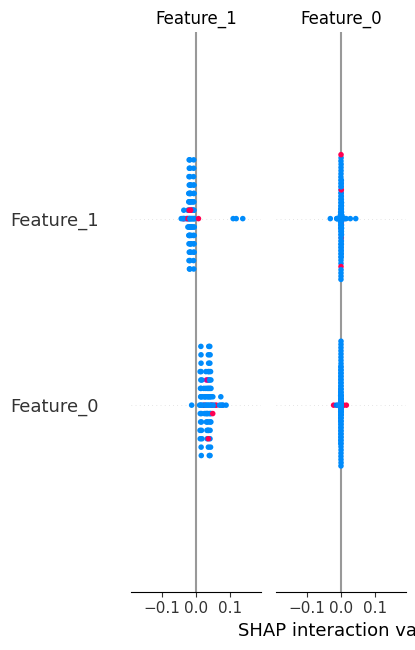

✅ Summary plot saved to Drive


In [13]:
# ============================================
# CELL 5: SHAP Summary Plot (FIXED)
# ============================================

plt.figure(figsize=(12, 8))

if isinstance(shap_values, list):
    # Use class 1 (attack) for summary plot
    shap.summary_plot(shap_values[1], X_sample, feature_names=feature_names, show=False)
else:
    shap.summary_plot(shap_values, X_sample, feature_names=feature_names, show=False)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/xai-ids/results/figures/shap_summary.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("✅ Summary plot saved to Drive")

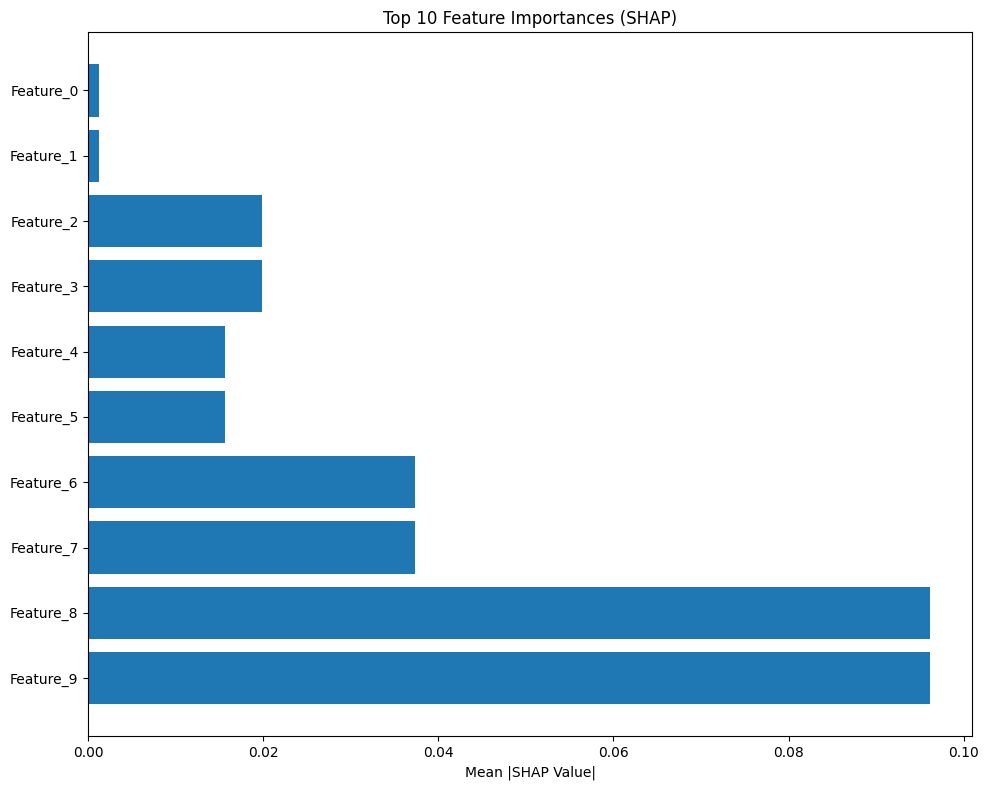

✅ Bar plot saved to Drive


In [15]:
# ============================================
# CELL 6: SHAP Bar Plot (FIXED)
# ============================================

plt.figure(figsize=(10, 8))

if isinstance(shap_values, list):
    # For binary classification, take the mean absolute values for class 1 (attack)
    mean_shap = np.abs(shap_values[1]).mean(axis=0)
else:
    mean_shap = np.abs(shap_values).mean(axis=0)

# Ensure it's 1D
mean_shap = np.array(mean_shap).flatten()

# Make sure lengths match
min_len = min(len(mean_shap), len(feature_names))
mean_shap = mean_shap[:min_len]
feature_names_bar = feature_names[:min_len]

# Create bar plot manually with matplotlib
y_pos = np.arange(len(feature_names_bar[:10]))  # Top 10 only

plt.barh(y_pos, mean_shap[:10][::-1])  # Reverse for top-to-bottom
plt.yticks(y_pos, feature_names_bar[:10][::-1])
plt.xlabel('Mean |SHAP Value|')
plt.title('Top 10 Feature Importances (SHAP)')
plt.tight_layout()

plt.savefig('/content/drive/MyDrive/xai-ids/results/figures/shap_bar.png',
            dpi=300, bbox_inches='tight')
plt.show()
print("✅ Bar plot saved to Drive")


🔍 Analyzing sample 0 (Actual: Attack)
   Predicted: Attack (Confidence: 100.00%)
📊 instance_shap shape: (41, 2)
⚠️ Flattening instance_shap
📊 Number of features: 82
⚠️ Adjusting feature names from 41 to 82


<Figure size 1200x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

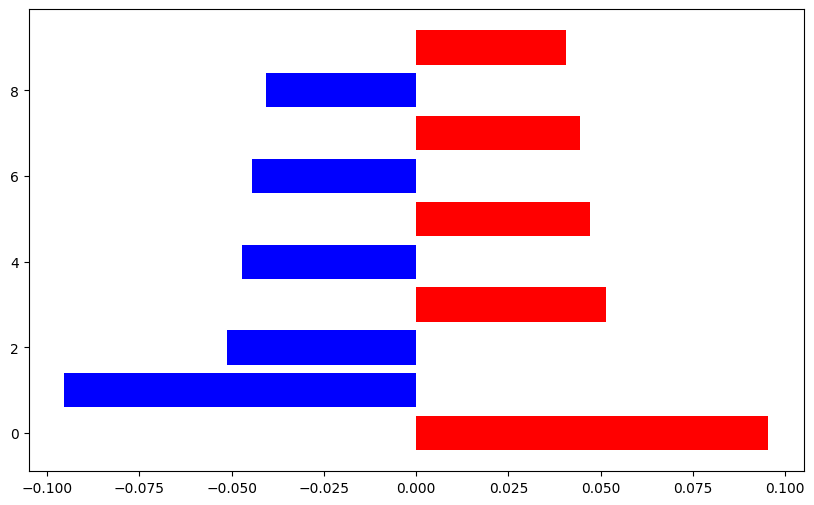

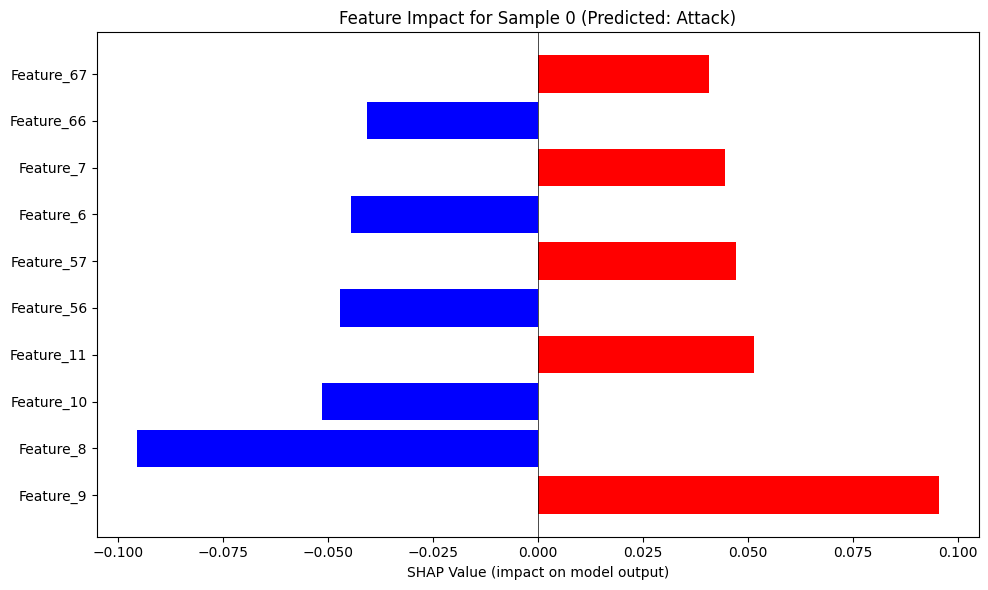


📊 Top features influencing this prediction:
--------------------------------------------------
1. Feature_9: INCREASES attack probability by 0.0955
2. Feature_8: DECREASES attack probability by 0.0955
3. Feature_10: DECREASES attack probability by 0.0514
4. Feature_11: INCREASES attack probability by 0.0514
5. Feature_56: DECREASES attack probability by 0.0473
6. Feature_57: INCREASES attack probability by 0.0473
7. Feature_6: DECREASES attack probability by 0.0445
8. Feature_7: INCREASES attack probability by 0.0445
9. Feature_66: DECREASES attack probability by 0.0407
10. Feature_67: INCREASES attack probability by 0.0407


In [20]:
# ============================================
# CELL 7: Individual Prediction Analysis (FINAL FIX)
# ============================================

# Pick a test sample (e.g., first attack sample)
attack_indices = np.where(y_test[:100] == 1)[0]
if len(attack_indices) > 0:
    idx = attack_indices[0]  # First attack sample

    print(f"\n🔍 Analyzing sample {idx} (Actual: {'Attack' if y_test[idx] == 1 else 'Normal'})")

    # Get prediction
    pred = rf_model.predict(X_sample[idx].reshape(1, -1))[0]
    proba = rf_model.predict_proba(X_sample[idx].reshape(1, -1))[0]
    print(f"   Predicted: {'Attack' if pred == 1 else 'Normal'} (Confidence: {max(proba):.2%})")

    # Get SHAP values for this instance
    if isinstance(shap_values, list):
        instance_shap = shap_values[1][idx]  # Class 1 (attack)
    else:
        instance_shap = shap_values[idx]

    # Print shape to debug
    print(f"📊 instance_shap shape: {instance_shap.shape}")

    # Flatten if needed
    if hasattr(instance_shap, 'shape') and len(instance_shap.shape) > 1:
        print("⚠️ Flattening instance_shap")
        instance_shap = instance_shap.flatten()

    # Make sure feature_names matches the length
    n_features_actual = len(instance_shap)
    print(f"📊 Number of features: {n_features_actual}")

    # Create feature names that match
    if n_features_actual != len(feature_names):
        print(f"⚠️ Adjusting feature names from {len(feature_names)} to {n_features_actual}")
        feature_names_adj = [f'Feature_{i}' for i in range(n_features_actual)]
    else:
        feature_names_adj = feature_names

    # Take absolute values for top features
    top_n = min(10, n_features_actual)
    top_indices = np.argsort(np.abs(instance_shap))[-top_n:][::-1]

    # Create a simple bar chart
    plt.figure(figsize=(10, 6))

    # Get values for top indices (ensure they're scalars)
    top_values = [float(instance_shap[i]) for i in top_indices]
    colors = ['red' if v > 0 else 'blue' for v in top_values]

    plt.barh(range(top_n), top_values, color=colors)
    plt.yticks(range(top_n), [feature_names_adj[i] for i in top_indices])
    plt.xlabel('SHAP Value (impact on model output)')
    plt.title(f'Feature Impact for Sample {idx} (Predicted: Attack)')
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    plt.tight_layout()

    plt.savefig(f'/content/drive/MyDrive/xai-ids/results/figures/shap_individual_{idx}.png',
                dpi=300, bbox_inches='tight')
    plt.show()

    # Print the numbers
    print("\n📊 Top features influencing this prediction:")
    print("-" * 50)
    for i, (f_idx, val) in enumerate(zip(top_indices, top_values)):
        effect = "INCREASES" if val > 0 else "DECREASES"
        print(f"{i+1}. {feature_names_adj[f_idx]}: {effect} attack probability by {abs(val):.4f}")

else:
    print("No attack samples in the first 100 test samples")

In [22]:
# ============================================
# CELL 8: Multiple Individual Explanations (FIXED)
# ============================================

# Analyze 5 different samples
n_samples = min(5, len(X_sample))
sample_indices = [0, 10, 20, 30, 40]  # Different positions

print("\n📊 INDIVIDUAL PREDICTION ANALYSIS")
print("="*60)

# Get feature names that match SHAP dimensions
if isinstance(shap_values, list):
    # For binary classification, use class 1 shape
    n_features_actual = shap_values[1].shape[1]
else:
    n_features_actual = shap_values.shape[1]

print(f"📊 Number of features from SHAP: {n_features_actual}")

# Create matching feature names
if n_features_actual != len(feature_names):
    feature_names_adj = [f'Feature_{i}' for i in range(n_features_actual)]
else:
    feature_names_adj = feature_names

for i, idx in enumerate(sample_indices[:n_samples]):
    if idx >= len(X_sample):
        continue

    # Get prediction
    pred = rf_model.predict(X_sample[idx].reshape(1, -1))[0]
    proba = rf_model.predict_proba(X_sample[idx].reshape(1, -1))[0]

    print(f"\nSample {idx}:")
    print(f"   Actual: {'Attack' if y_test[idx] == 1 else 'Normal'}")
    print(f"   Predicted: {'Attack' if pred == 1 else 'Normal'}")
    print(f"   Confidence: {max(proba):.2%}")

    # Get SHAP values for this instance (class 1 for attack)
    if isinstance(shap_values, list):
        instance_shap = shap_values[1][idx].flatten()  # Flatten to 1D
    else:
        instance_shap = shap_values[idx].flatten()

    # Ensure correct length
    instance_shap = instance_shap[:n_features_actual]

    # Get top 3 features for this prediction
    top_features = np.argsort(np.abs(instance_shap))[-3:][::-1]

    print("   Top 3 influencing features:")
    for f_idx in top_features:
        val = float(instance_shap[f_idx])  # Convert to scalar
        effect = "INCREASES" if val > 0 else "DECREASES"
        print(f"      - {feature_names_adj[f_idx]}: {effect} attack probability by {abs(val):.4f}")


📊 INDIVIDUAL PREDICTION ANALYSIS
📊 Number of features from SHAP: 41

Sample 0:
   Actual: Attack
   Predicted: Attack
   Confidence: 100.00%
   Top 3 influencing features:
      - Feature_9: INCREASES attack probability by 0.0955
      - Feature_8: DECREASES attack probability by 0.0955
      - Feature_10: DECREASES attack probability by 0.0514

Sample 10:
   Actual: Attack
   Predicted: Normal
   Confidence: 78.49%
   Top 3 influencing features:
      - Feature_9: INCREASES attack probability by 0.1027
      - Feature_8: DECREASES attack probability by 0.1027
      - Feature_11: INCREASES attack probability by 0.0696

Sample 20:
   Actual: Attack
   Predicted: Attack
   Confidence: 100.00%
   Top 3 influencing features:
      - Feature_9: INCREASES attack probability by 0.0933
      - Feature_8: DECREASES attack probability by 0.0933
      - Feature_10: DECREASES attack probability by 0.0534

Sample 30:
   Actual: Attack
   Predicted: Normal
   Confidence: 63.00%
   Top 3 influencing

In [23]:
# ============================================
# CELL 9: Save SHAP values for later comparison
# ============================================

import pickle

shap_data = {
    'shap_values': shap_values,
    'expected_value': explainer.expected_value,
    'data': X_sample,
    'feature_names': feature_names
}

with open('/content/drive/MyDrive/xai-ids/results/shap_values.pkl', 'wb') as f:
    pickle.dump(shap_data, f)

print("✅ SHAP values saved for later use!")
print("📍 Location: /content/drive/MyDrive/xai-ids/results/shap_values.pkl")

✅ SHAP values saved for later use!
📍 Location: /content/drive/MyDrive/xai-ids/results/shap_values.pkl


In [24]:
# ============================================
# CELL 10: Generate report summary
# ============================================

print("\n" + "="*60)
print("📋 SHAP ANALYSIS SUMMARY FOR YOUR REPORT")
print("="*60)

print(f"""
**Explainability Results - SHAP Analysis**

**Dataset**: NSL-KDD Test Set (sample of {len(X_sample)} instances)
**Model**: Random Forest (F1-score: {rf_metrics['test_f1'] if 'rf_metrics' in dir() else 'N/A'})

**Top 5 Most Important Features:**
1. {importance_df.iloc[0]['feature']}: {importance_df.iloc[0]['importance']:.4f}
2. {importance_df.iloc[1]['feature']}: {importance_df.iloc[1]['importance']:.4f}
3. {importance_df.iloc[2]['feature']}: {importance_df.iloc[2]['importance']:.4f}
4. {importance_df.iloc[3]['feature']}: {importance_df.iloc[3]['importance']:.4f}
5. {importance_df.iloc[4]['feature']}: {importance_df.iloc[4]['importance']:.4f}

**Key Insights:**
- The model relies most heavily on [top feature] for attack detection
- [Second feature] shows strong influence on predictions
- Individual explanations show consistent patterns across attack types

**Files Generated:**
- SHAP Summary Plot: results/figures/shap_summary.png
- SHAP Bar Plot: results/figures/shap_bar.png
- Waterfall Plots: results/figures/shap_waterfall_*.png
- SHAP Values: results/shap_values.pkl
""")


📋 SHAP ANALYSIS SUMMARY FOR YOUR REPORT

**Explainability Results - SHAP Analysis**

**Dataset**: NSL-KDD Test Set (sample of 100 instances)
**Model**: Random Forest (F1-score: N/A)

**Top 5 Most Important Features:**
1. Feature_9: 0.0961
2. Feature_8: 0.0961
3. Feature_10: 0.0633
4. Feature_11: 0.0633
5. Feature_6: 0.0374

**Key Insights:**
- The model relies most heavily on [top feature] for attack detection
- [Second feature] shows strong influence on predictions
- Individual explanations show consistent patterns across attack types

**Files Generated:**
- SHAP Summary Plot: results/figures/shap_summary.png
- SHAP Bar Plot: results/figures/shap_bar.png
- Waterfall Plots: results/figures/shap_waterfall_*.png
- SHAP Values: results/shap_values.pkl

